# Calculating the photolysis rates

In [1]:
import isochem
import numpy as np
import matplotlib.pyplot as plt
import time

## 1. Reading atmospheric file

In [15]:
### Reading input file with atmospheric profiles

#Reading the HDF5 file
hlay,Tlay,gasID,isoID,Nlay1,ztime = isochem.utils.read_hdf5('mars_mcd_aphelion_ini')
nlay = Nlay1.shape[0]
ngas = Nlay1.shape[1]
nt = len(ztime)

#Using the last timestep as the initial condition for the model
Nlay = np.zeros((nlay,ngas),dtype='float64')
Nlay[:,:] = Nlay1[:,:,nt-1]

#Calculating VMRs and total density
N0lay = np.sum(Nlay,axis=1)
VMRlay = np.transpose(np.transpose(Nlay)/N0lay)

#Calculating the pressure
Play = N0lay * isochem.phys_const['k_B'] * Tlay
    

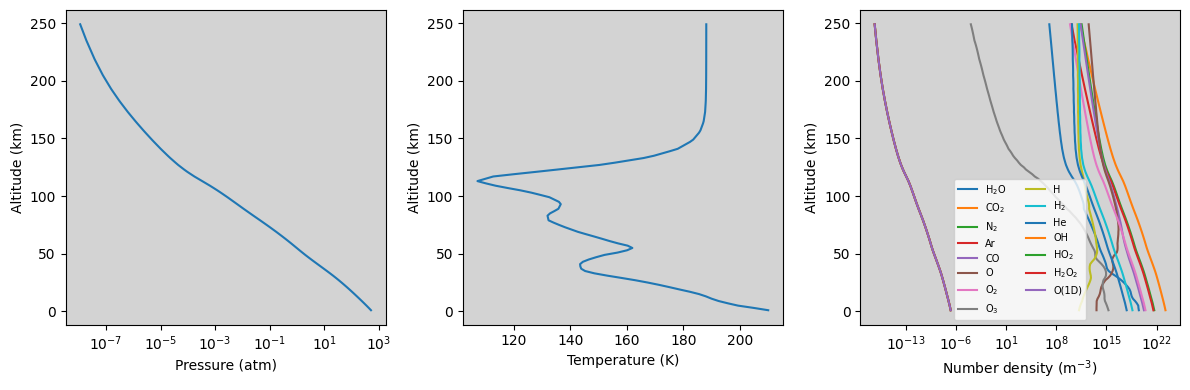

In [16]:
#Plotting the vertical profiles from the files
fig,(ax1,ax2,ax3) = plt.subplots(1,3,figsize=(12,4))

ax1.plot(Play,hlay/1.0e3)
ax1.set_xscale('log')
ax1.set_xlabel('Pressure (atm)')
ax1.set_ylabel('Altitude (km)')
ax1.set_facecolor('lightgray')

ax2.plot(Tlay,hlay/1.0e3)
ax2.set_xlabel('Temperature (K)')
ax2.set_ylabel('Altitude (km)')
ax2.set_facecolor('lightgray')

for i in range(ngas):
    label = isochem.id_to_label(gasID[i],isoID[i])
    ax3.plot(Nlay[:,i],hlay/1.0e3,label=label)
ax3.set_xscale('log')
ax3.legend(fontsize=7,ncol=2)
ax3.set_xlabel('Number density (m$^{-3}$)')
ax3.set_ylabel('Altitude (km)')
ax3.set_facecolor('lightgray')

plt.tight_layout()

## 2. Setting up photolysis scheme

In [17]:
filename = 'reference_xs'
solname = '/home/alday/Documents/Projects/isochem-dist/data/Solar_Spectrum/atlas3_thuillier_tuv'
wl,wc,wu,solflux,sID_xs,sISO_xs,xs,nreactions,sID,sISO,npr,pID,pISO,pf,xsr = isochem.photolysis.setup_photolysis(filename,solname,gasID,isoID,Tlay)

In [18]:
#Printing the available reactions considering the cross section and atmospheric files
for j in range(nreactions):
    strx = isochem.photolysis.print_photolysis_reaction(sID[j],sISO[j],npr[j],pID[:,j],pISO[:,j],pf[:,j])
    print('Reaction '+str(j+1),strx)

Reaction 1 CO2 + hv ---> CO + O
Reaction 2 CO2 + hv ---> CO + O(1D)
Reaction 3 H2 + hv ---> 2*H
Reaction 4 H2O + hv ---> OH + H
Reaction 5 H2O2 + hv ---> 2*OH
Reaction 6 HO2 + hv ---> OH + O
Reaction 7 O2 + hv ---> 2*O
Reaction 8 O2 + hv ---> O + O(1D)
Reaction 9 O3 + hv ---> O2 + O
Reaction 10 O3 + hv ---> O2 + O(1D)


## 3. Calculating the photolysis rates

In [19]:
zen = 0.  #Solar zenith angle

In [20]:
start = time.time()
rrates = isochem.photolysis.photolysis_rates(hlay,gasID,isoID,Nlay,wl,wu,wc,sID_xs,sISO_xs,xs,xsr,solflux,planet='Mars',zen=zen,tau_aero=0.,radius=3393.,galb=0.3,dist_sun=1.5)
print('elapsed time = ',time.time()-start,'s')

elapsed time =  0.13463973999023438 s


Text(0, 0.5, 'Altitude (km)')

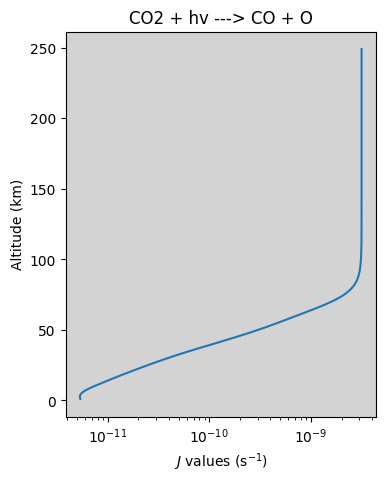

In [22]:
fig,ax1 = plt.subplots(1,1,figsize=(4,5))

ir = 0
strx = isochem.photolysis.print_photolysis_reaction(sID[ir],sISO[ir],npr[ir],pID[:,ir],pISO[:,ir],pf[:,ir])
ax1.plot(rrates[:,ir],hlay/1.0e3)
ax1.set_title(strx)
ax1.set_xscale('log')
ax1.set_facecolor('lightgray')
ax1.set_xlabel('$J$ values (s$^{-1}$)')
ax1.set_ylabel('Altitude (km)')
#ax1.set_xlim(left=1.0e-15,right=1.0e-8)